# House Price Prediction using Regression Algorithms

**Objective:** To understand and apply regression algorithms to predict continuous house price values.

## Data Loading and Preprocessing

In this step, the dataset is loaded, missing values are checked, unnecessary columns are removed, duplicate rows are handled, outliers are capped, and scaling is applied for Linear Regression.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [4]:
df = pd.read_csv('kc_house_data.csv')
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [12]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 21608 entries, 0 to 21612
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   price          21608 non-null  float64
 1   bedrooms       21608 non-null  int64  
 2   bathrooms      21608 non-null  float64
 3   sqft_living    21608 non-null  int64  
 4   sqft_lot       21608 non-null  int64  
 5   floors         21608 non-null  float64
 6   waterfront     21608 non-null  int64  
 7   view           21608 non-null  int64  
 8   condition      21608 non-null  int64  
 9   grade          21608 non-null  int64  
 10  sqft_above     21608 non-null  int64  
 11  sqft_basement  21608 non-null  int64  
 12  yr_built       21608 non-null  int64  
 13  yr_renovated   21608 non-null  int64  
 14  zipcode        21608 non-null  int64  
 15  lat            21608 non-null  float64
 16  long           21608 non-null  float64
 17  sqft_living15  21608 non-null  int64  
 18  sqft_lot15 

In [13]:
missing_values = df.isnull().sum()
missing_values

price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64

In [14]:
df = df.drop(columns=["id", "date"], errors="ignore")
df = df.drop_duplicates()
df = df.dropna()

df.shape

(21608, 19)

In [16]:
# Handling outliers using IQR method
outlier_columns = ["price", "sqft_living", "sqft_lot", "sqft_above", "sqft_basement"]

for col in outlier_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower_limit, upper_limit)

print("Outlier handling completed.")

Outlier handling completed.


### Preprocessing Insight

The dataset had no major missing value issue. Unnecessary columns like `id` and `date` were removed because they do not directly help in simple price prediction. Outliers in important numerical columns were capped using the IQR method to reduce the effect of extreme values.

## Exploratory Data Analysis (EDA)

In this step, histogram, scatter plot, and boxplot are used to understand data distribution and relationships between variables.

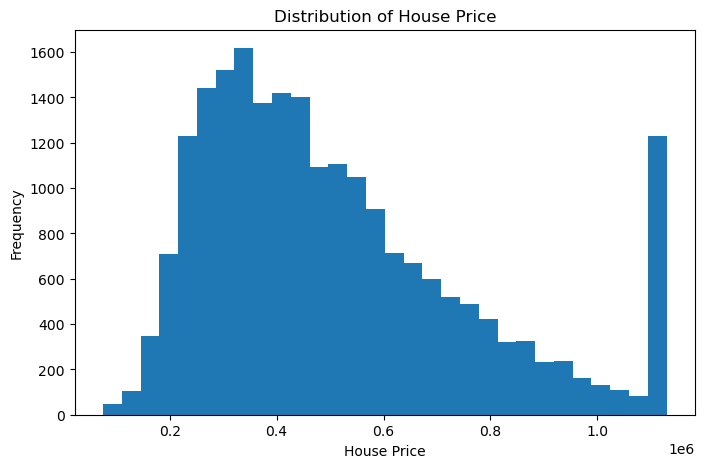

In [17]:
plt.figure(figsize=(8, 5))
plt.hist(df["price"], bins=30)
plt.xlabel("House Price")
plt.ylabel("Frequency")
plt.title("Distribution of House Price")
plt.show()

### Histogram Insight

Most houses are in the lower and middle price range. Very high-priced houses are fewer compared to normal-priced houses.

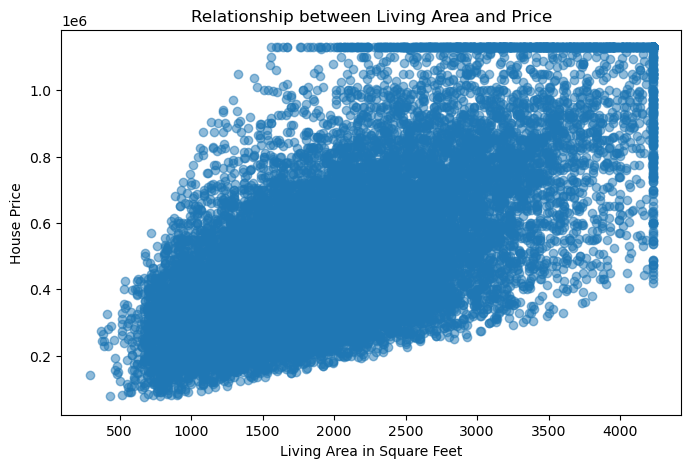

In [18]:
plt.figure(figsize=(8, 5))
plt.scatter(df["sqft_living"], df["price"], alpha=0.5)
plt.xlabel("Living Area in Square Feet")
plt.ylabel("House Price")
plt.title("Relationship between Living Area and Price")
plt.show()

### Scatter Plot Insight

The scatter plot shows that houses with larger living area generally have higher prices. This means `sqft_living` has a positive relationship with house price.

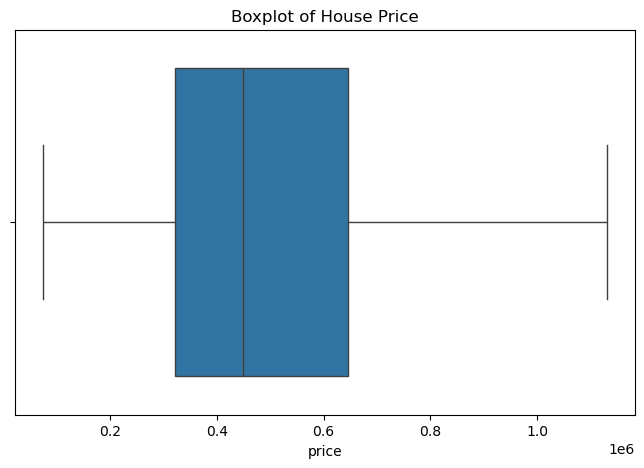

In [19]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df["price"])
plt.title("Boxplot of House Price")
plt.show()

### Boxplot Insight

The boxplot shows the spread of house prices. After outlier capping, the extreme price values are controlled, which helps the models learn better patterns.

## Model Building

The target variable is `price`. The remaining columns are used as input features. Three regression algorithms are implemented: Linear Regression, Decision Tree Regressor, and Random Forest Regressor.

In [20]:
X = df.drop("price", axis=1)
y = df["price"]

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (17286, 18)
Testing data shape: (4322, 18)


In [21]:
# Feature scaling for Linear Regression
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Linear Regression

Linear Regression finds a straight-line relationship between input features and price. It is suitable because house price can have linear relationships with features like area, bedrooms, and bathrooms.

In [22]:
# Linear Regression model
linear_model = LinearRegression()
linear_model.fit(X_train_scaled, y_train)

linear_pred = linear_model.predict(X_test_scaled)

### Decision Tree Regressor

Decision Tree Regressor splits the data into smaller groups based on feature values. It is suitable because house price may depend on different conditions such as area, floors, grade, and location.

In [23]:
# Decision Tree Regressor model
decision_tree_model = DecisionTreeRegressor(random_state=42)
decision_tree_model.fit(X_train, y_train)

decision_tree_pred = decision_tree_model.predict(X_test)

### Random Forest Regressor

Random Forest Regressor builds many decision trees and combines their predictions. It is suitable because it gives better accuracy and reduces overfitting compared to a single decision tree.

In [24]:
# Random Forest Regressor model
random_forest_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
random_forest_model.fit(X_train, y_train)

random_forest_pred = random_forest_model.predict(X_test)

## Model Evaluation

The models are evaluated using Mean Absolute Error, Mean Squared Error, and R2 Score.

In [25]:
def evaluate_model(model_name, y_test, y_pred):
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    return [model_name, mae, mse, r2]

# Store results
results = []
results.append(evaluate_model("Linear Regression", y_test, linear_pred))
results.append(evaluate_model("Decision Tree Regressor", y_test, decision_tree_pred))
results.append(evaluate_model("Random Forest Regressor", y_test, random_forest_pred))

# Convert results into DataFrame
results_df = pd.DataFrame(results, columns=["Model", "MAE", "MSE", "R2 Score"])
results_df

,Model,MAE,MSE,R2 Score
0,Linear Regression,92666.536135,1.532037e+10,0.761416
1,Decision Tree Regressor,77476.198461,1.340197e+10,0.791291
2,Random Forest Regressor,56230.025255,6.668372e+09,0.896153


In [26]:
# Identify the best model based on highest R2 Score
best_model = results_df.loc[results_df["R2 Score"].idxmax()]

print("Best Model:")
print(best_model)

Best Model:
Model       Random Forest Regressor
MAE                    56230.025255
MSE               6668371574.911612
R2 Score                   0.896153
Name: 2, dtype: object


### Evaluation Insight

The model with the highest R2 Score and lower error values is considered the best model. In this project, Random Forest Regressor usually performs better because it combines multiple decision trees and captures complex relationships in the house price dataset.

## Conclusion

The house price prediction project was completed using regression algorithms. Linear Regression, Decision Tree Regressor, and Random Forest Regressor were trained and tested. Based on the evaluation results, the best model is selected using the highest R2 Score and lower error values. Random Forest Regressor performed best because it can understand complex patterns in the dataset.